In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report
)

In [2]:
df = sns.load_dataset("penguins")
df.at[336, 'sex'] = "FEMALE"
df = df.dropna()

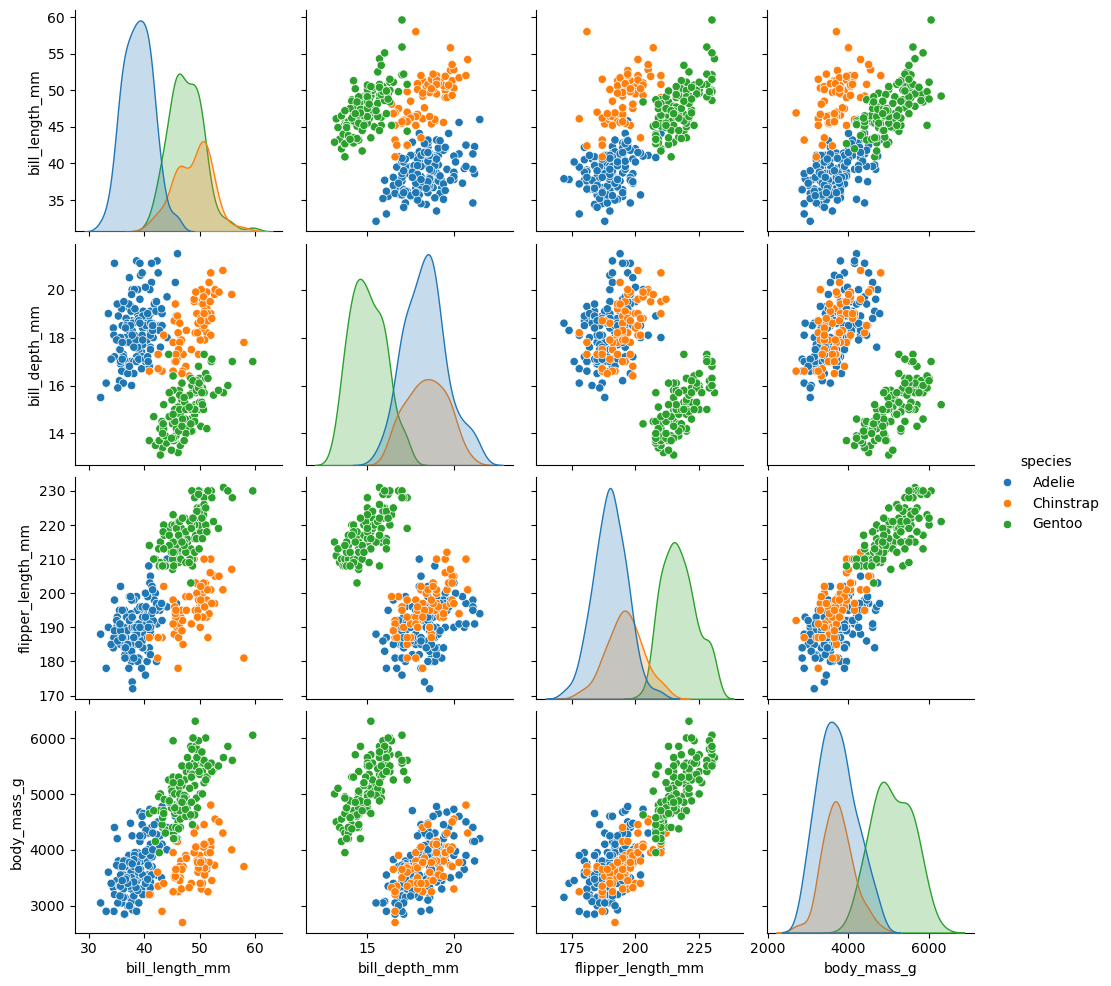

In [3]:
sns.pairplot(df, hue="species")

In [4]:
X = pd.get_dummies(df.drop("species", axis=1), drop_first=True)
y = df["species"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=101
)
X_train

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,island_Dream,island_Torgersen,sex_Female,sex_Male
194,50.9,19.1,196.0,3550.0,True,False,False,True
22,35.9,19.2,189.0,3800.0,False,False,True,False
92,34.0,17.1,185.0,3400.0,True,False,True,False
149,37.8,18.1,193.0,3750.0,True,False,False,True
156,52.7,19.8,197.0,3725.0,True,False,False,True
...,...,...,...,...,...,...,...,...
81,42.9,17.6,196.0,4700.0,False,True,False,True
93,39.6,18.1,186.0,4450.0,True,False,False,True
69,41.8,19.4,198.0,4450.0,False,True,False,True
335,55.1,16.0,230.0,5850.0,False,False,False,True


In [5]:
model = DecisionTreeClassifier()

model.fit(X_train, y_train)

base_preds = model.predict(X_test)

print(classification_report(y_test, base_preds))
print(confusion_matrix(y_test, base_preds))

              precision    recall  f1-score   support

      Adelie       0.95      0.98      0.96        41
   Chinstrap       0.95      0.91      0.93        23
      Gentoo       1.00      1.00      1.00        37

    accuracy                           0.97       101
   macro avg       0.97      0.96      0.97       101
weighted avg       0.97      0.97      0.97       101

[[40  1  0]
 [ 2 21  0]
 [ 0  0 37]]


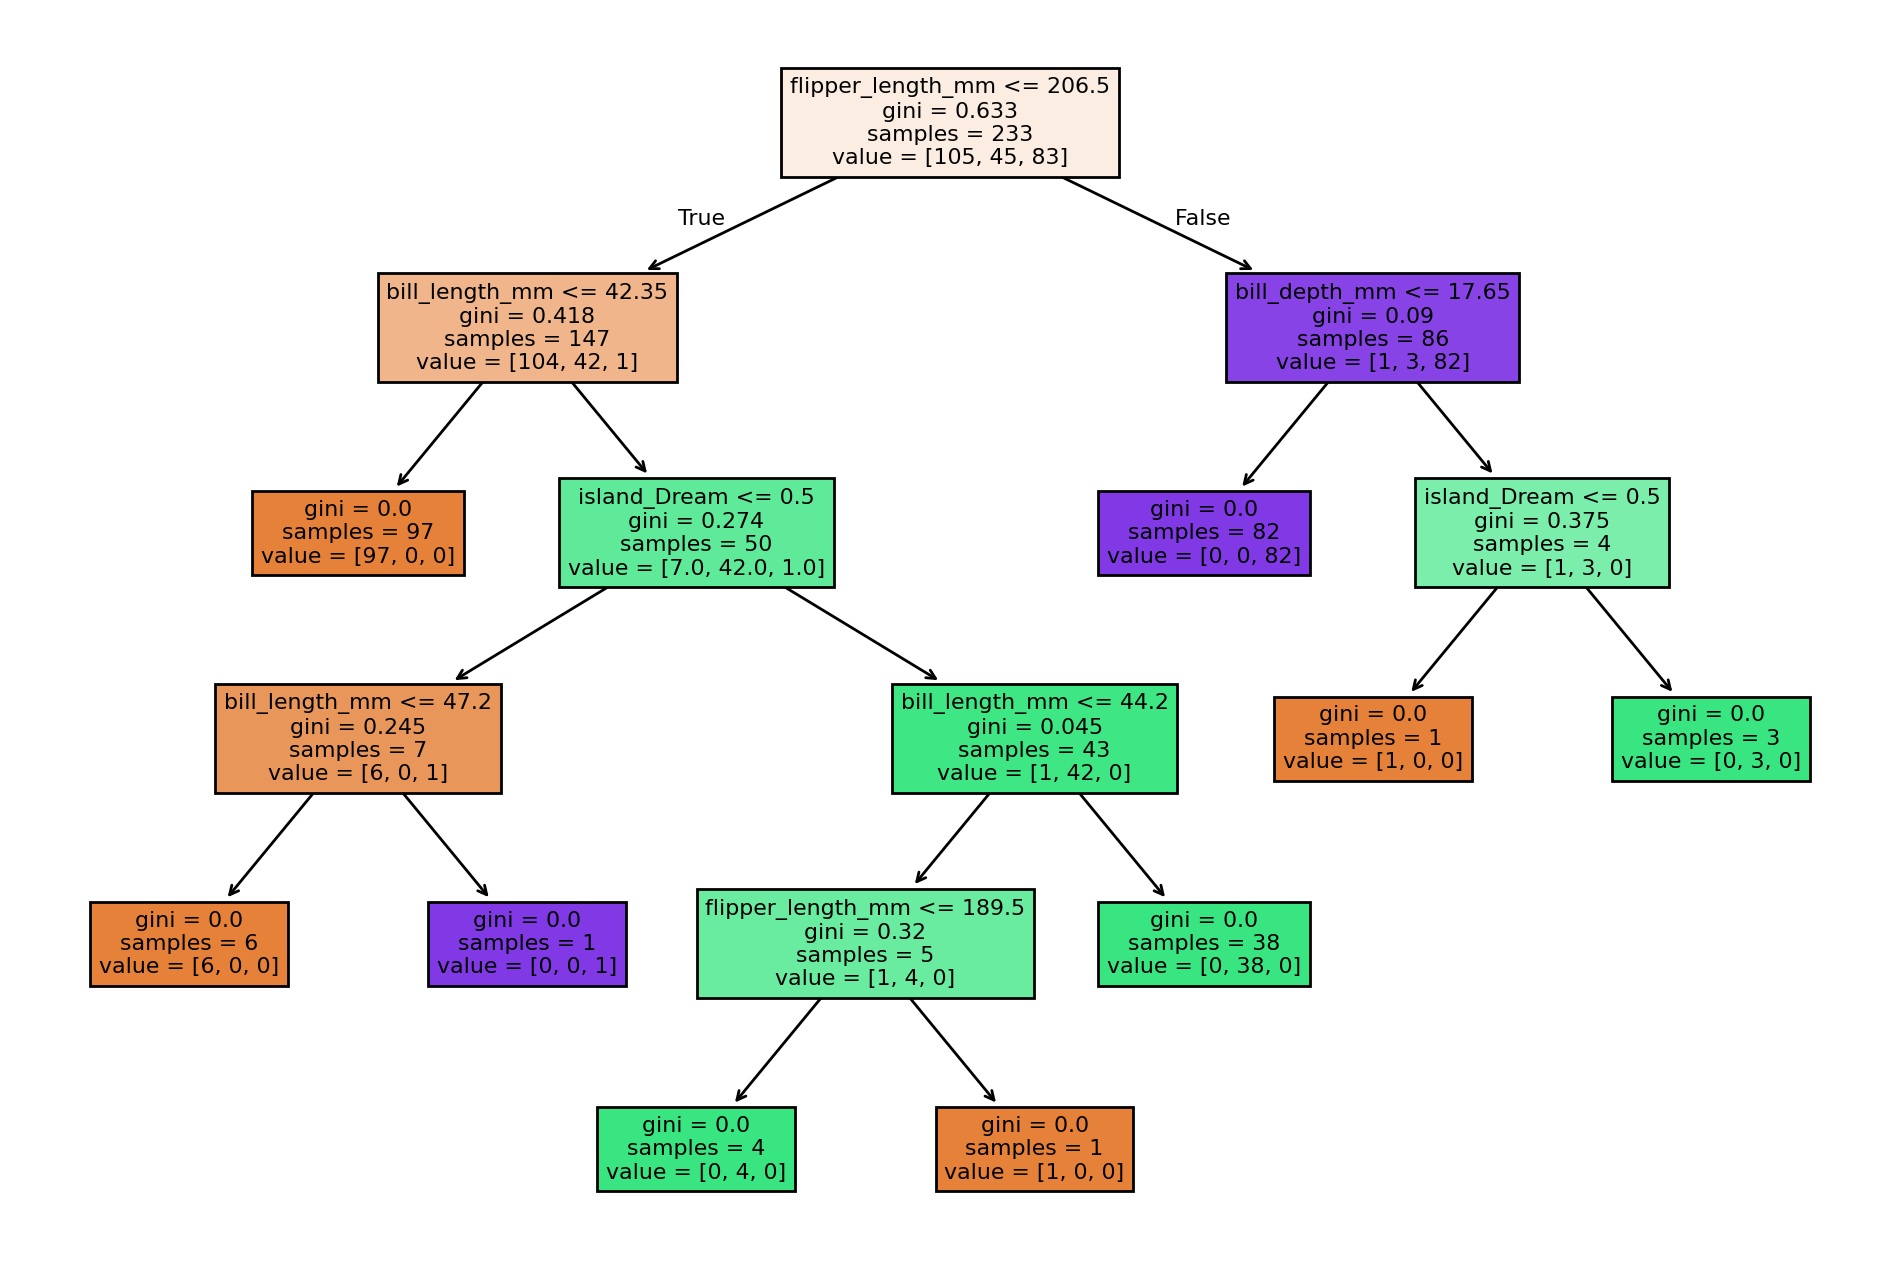

In [7]:
plt.figure(figsize=(12, 8), dpi=200)
plot_tree(model, feature_names=X.columns.to_list(), filled=True)
plt.show()